# Задача 6: Резонансная кривая при нелинейном взаимодействии пучок-частица

**Условие:**
Качественно нарисуйте ожидаемую резонансную кривую, предположив, что нелинейность колебаний возникает из-за нелинейной зависимости силы взаимодействия пучка и частицы от координаты (возьмите одномерную кривую $\Delta \nu_b(a)$).

**Теоретическое обоснование (Метод усредненного Гамильтониана):**

Для точного построения резонансной кривой воспользуемся методом усреднения. Это стандартный подход в физике ускорителей для анализа резонансов.

1.  **Исходный Гамильтониан:**
    Рассмотрим движение частицы под действием нелинейной силы пучка и внешней возмущающей силы (драйвера).
    В переменных действие-угол $(J, \psi)$ гамильтониан имеет вид:
    $$ H(J, \psi, \theta) = H_0(J) + \epsilon V(J, \psi, \theta) $$
    *   $H_0(J)$ описывает свободные нелинейные колебания. Частота колебаний зависит от амплитуды: $\nu(J) = \frac{\partial H_0}{\partial J}$.
    *   Возмущение $V \propto x \cdot F_{drive}(\theta) \propto \sqrt{2J} \cos\psi \cdot \cos(\nu_{dr}\theta)$.

2.  **Выделение резонансного члена:**
    Произведение косинусов дает суммы и разности фаз: $\cos(\psi - \nu_{dr}\theta)$ и $\cos(\psi + \nu_{dr}\theta)$.
    Вблизи резонанса $\nu(J) \approx \nu_{dr}$ фаза $\psi - \nu_{dr}\theta$ меняется медленно, а $\psi + \nu_{dr}\theta$ — быстро.
    Усредняя по быстрым осцилляциям, оставляем только медленный (резонансный) член:
    $$ H \approx H_0(J) + \epsilon_{eff} \sqrt{2J} \cos(\psi - \nu_{dr}\theta) $$

3.  **Переход во вращающуюся систему отсчета:**
    Сделаем каноническое преобразование к "медленной фазе" $\phi = \psi - \nu_{dr}\theta$.
    Новый гамильтониан $K = H - \nu_{dr} J$ (так как $\frac{\partial \phi}{\partial \theta} = -\nu_{dr}$):
    $$ K(J, \phi) = \underbrace{(H_0(J) - \nu_{dr} J)}_{\text{Расстройка}} + \underbrace{\epsilon_{eff} \sqrt{2J} \cos\phi}_{\text{Драйвер}} $$
    
    Производная первого члена по $J$ дает расстройку частоты: $\frac{\partial}{\partial J}(H_0 - \nu_{dr} J) = \nu(J) - \nu_{dr}$.

4.  **Стационарные точки (Резонансная кривая):**
    Установившаяся амплитуда колебаний соответствует неподвижной точке в фазовом пространстве $(J, \phi)$, то есть $\dot{J}=0$ и $\dot{\phi}=0$.

    *   **Уравнение для действия ($\dot{J}=0$):**
        $$ \dot{J} = -\frac{\partial K}{\partial \phi} = \epsilon_{eff} \sqrt{2J} \sin\phi = 0 $$
        Отсюда следует, что фаза $\phi$ должна быть либо $0$, либо $\pi$.
        Это значит, что частица колеблется либо **в фазе** с силой, либо в **противофазе**.

    *   **Уравнение для фазы ($\dot{\phi}=0$):**
        $$ \dot{\phi} = \frac{\partial K}{\partial J} = (\nu(J) - \nu_{dr}) \pm \frac{\epsilon_{eff}}{\sqrt{2J}} = 0 $$
        (Знак $\pm$ берется из $\cos\phi = \pm 1$).

5.  **Итоговое уравнение:**
    Переходя от действия $J$ к амплитуде $A$ (учитывая, что $\sqrt{2J} \sim A$), получаем уравнение баланса частот:
    $$ \nu_{dr} = \nu(A) \pm \frac{C}{A} $$
    
    *   $\nu(A)$ — это "скелетная кривая" (собственная частота).
    *   $\pm \frac{C}{A}$ — это ширина резонанса, создаваемая внешней силой. Чем больше амплитуда $A$, тем слабее влияние внешней силы на частоту (член $1/A$ убывает).

    Именно это уравнение мы используем в коде для построения точных границ резонанса.

**Пояснение к графикам (Случай отталкивания):**
*   Сила взаимодействия **отталкивающая** ($\xi < 0$).
*   Скелетная кривая наклонена **вправо** (Hardening spring).
*   Резонансные ветви $\nu(A) \pm C/A$ образуют "язык", наклоненный вправо.

<>:46: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\D'
<>:82: SyntaxWarning: invalid escape sequence '\s'
<>:46: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\D'
<>:82: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2637/914884857.py:46: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_xlabel('Амплитуда $A / \sigma$')
/tmp/ipykernel_2637/914884857.py:47: SyntaxWarning: invalid escape sequence '\D'
  ax1.set_ylabel('Нормированный сдвиг $\Delta \\nu(A) / |\\xi|$')
/tmp/ipykernel_2637/914884857.py:82: SyntaxWarning: invalid escape sequence '\s'
  ax2.set_ylabel('Амплитуда $A / \sigma$')


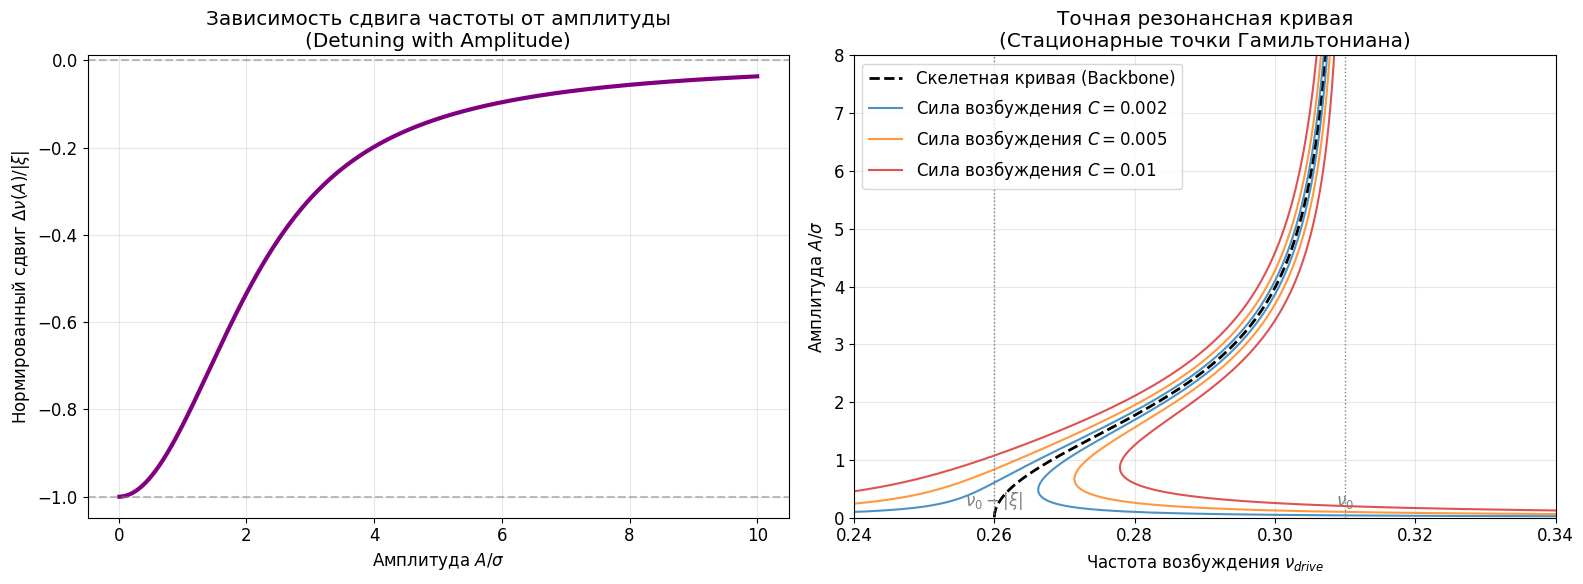

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import i0

# Настройка графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

def beam_beam_tune_shift_1d(amplitude, sigma, xi):
    """
    Вычисляет сдвиг частоты для 1D гауссова пучка.
    Delta_nu / xi = (2/J) * (1 - exp(-J/2)*I0(J/2))
    где J = (amplitude / sigma)^2 / 2
    """
    amp = np.array(amplitude)
    # Избегаем деления на ноль в J
    amp_safe = np.where(amp < 1e-6, 1e-6, amp)
    J = (amp_safe**2) / (2 * sigma**2)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        factor = (2.0 / J) * (1.0 - np.exp(-J/2.0) * i0(J/2.0))
    
    # В нуле фактор равен 1
    factor = np.where(amp < 1e-6, 1.0, factor)
    
    return xi * factor

# Параметры
sigma = 1.0
xi = -0.05 # Отрицательный сдвиг (дефокусировка)
nu_0 = 0.31

# Амплитуды
amplitudes = np.linspace(0.01, 10*sigma, 1000) # Начинаем не с 0, чтобы не делить на 0 в C/A

# 1. Скелетная кривая (Backbone)
nu_backbone = nu_0 + beam_beam_tune_shift_1d(amplitudes, sigma, xi)

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- График 1: Сдвиг частоты ---
ax1.plot(amplitudes/sigma, (nu_backbone - nu_0)/abs(xi), linewidth=3, color='purple')
ax1.set_title('Зависимость сдвига частоты от амплитуды\n(Detuning with Amplitude)')
ax1.set_xlabel('Амплитуда $A / \sigma$')
ax1.set_ylabel('Нормированный сдвиг $\Delta \\nu(A) / |\\xi|$')
ax1.grid(True, alpha=0.3)
ax1.axhline(-1, color='gray', linestyle='--', alpha=0.5)
ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)

# --- График 2: Точная резонансная кривая ---
ax2.plot(nu_backbone, amplitudes/sigma, 'k--', linewidth=2, label='Скелетная кривая (Backbone)')

# Силы возбуждения (коэффициент C в формуле C/A)
# C пропорционально силе F. Подберем значения для наглядности.
C_values = [0.002, 0.005, 0.010] 
colors = ['tab:blue', 'tab:orange', 'tab:red']

for i, C in enumerate(C_values):
    # Уравнение границ резонанса: nu_dr = nu(A) +/- C/A
    # Это точное решение для стационарных точек усредненного гамильтониана
    
    term = C / (amplitudes/sigma) # C/A
    
    nu_left = nu_backbone - term
    nu_right = nu_backbone + term
    
    label = f'Сила возбуждения $C={C}$'
    
    # Рисуем левую и правую ветви
    # Чтобы график выглядел как единая кривая, можно соединить их
    # Но физически это границы гистерезиса
    ax2.plot(nu_left, amplitudes/sigma, color=colors[i], alpha=0.8, label=label)
    ax2.plot(nu_right, amplitudes/sigma, color=colors[i], alpha=0.8)
    
    # Закрасим область резонанса (где возможны скачки)
    # ax2.fill_betweenx(amplitudes/sigma, nu_left, nu_right, color=colors[i], alpha=0.1)

ax2.set_title('Точная резонансная кривая\n(Стационарные точки Гамильтониана)')
ax2.set_xlabel('Частота возбуждения $\\nu_{drive}$')
ax2.set_ylabel('Амплитуда $A / \sigma$')

# Настройка пределов
x_min = nu_0 + xi - 0.02
x_max = nu_0 + 0.03
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(0, 8)

# Линии
ax2.axvline(nu_0, color='gray', linestyle=':', linewidth=1)
ax2.text(nu_0, 0.2, '$\\nu_0$', ha='center', color='gray')
ax2.axvline(nu_0 + xi, color='gray', linestyle=':', linewidth=1)
ax2.text(nu_0 + xi, 0.2, '$\\nu_0 - |\\xi|$', ha='center', color='gray')

ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Сравнение с Задачей 5: Почему подходы разные?

Часто возникает вопрос: почему в Задаче 5 мы считали производную силы ($F'$), а здесь смотрим на профиль силы и усредняем его? И почему графики выглядят противоположно?

**1. Разные режимы колебаний:**

*   **Задача 5 (Малые колебания):**
    Мы рассматривали частицу, которая сидит в центре ($x \approx 0$) и чуть-чуть дрожит.
    В этом случае силу можно разложить в ряд: $F(x) \approx F(0) + F'(0)x$.
    Уравнение движения: $\ddot{x} + \underbrace{[-F'(0)]}_{\omega^2} x = 0$.
    Поэтому сдвиг частоты определялся **локальным градиентом** (производной) силы в точке равновесия.

*   **Задача 6 (Большие колебания):**
    Здесь амплитуда $A$ большая. Частица улетает далеко от центра, где линейное приближение $F \approx kx$ не работает.
    Частица "ощупывает" весь профиль силы. Эффективная частота определяется интегралом (усреднением) силы по траектории:
    $$ \Delta \nu(A) \propto \frac{1}{A} \oint F(x(t)) \cos(\psi) dt $$
    Поэтому здесь важна **сама форма силы** $F(x)$, а не только её наклон в центре.

**2. Разные аргументы графиков:**

*   **В Задаче 5** аргументом было **смещение пучков** $a$.
    *   При $a=0$ пучки компенсировали друг друга $\to$ Сила 0, Градиент 0 $\to$ Сдвиг 0.
    *   При росте $a$ компенсация нарушалась $\to$ Сдвиг рос.
    *   *График шел от 0 вверх.*

*   **В Задаче 6** аргументом является **амплитуда частицы** $A$.
    *   При $A=0$ частица в центре, где плотность заряда максимальна $\to$ Фокусировка максимальна.
    *   При росте $A$ частица большую часть времени проводит в "хвостах", где пучка почти нет $\to$ Фокусировка падает.
    *   *График идет от максимума вниз.*